In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from hydra import compose, initialize
from omegaconf import OmegaConf

from datasets import MultiMaze2dOfflineRLDataset
from algorithms.diffusion_forcing import DiffusionForcingPlanning

with initialize(version_base=None, config_path="configurations", job_name="debug"):
    cfg = compose(config_name="config")

dataset = MultiMaze2dOfflineRLDataset(cfg.dataset)
print(OmegaConf.to_yaml(cfg))
planner = DiffusionForcingPlanning(cfg.algorithm)

/users/dhoffmann/miniconda3/envs/df/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


experiment:
  debug: ${debug}
  tasks:
  - training
  num_nodes: 1
  training:
    precision: 16-mixed
    compile: false
    lr: 0.0005
    batch_size: 512
    max_epochs: 1000
    max_steps: 50000
    max_time: null
    data:
      num_workers: 8
      shuffle: true
    optim:
      accumulate_grad_batches: 1
      gradient_clip_val: 0
    checkpointing:
      every_n_train_steps: 10000
      every_n_epochs: null
      train_time_interval: null
      enable_version_counter: false
  validation:
    precision: 32
    compile: false
    batch_size: 128
    val_every_n_step: null
    val_every_n_epoch: 10
    limit_batch: 1
    inference_mode: false
    data:
      num_workers: 16
      shuffle: false
  test:
    precision: 16-mixed
    compile: false
    batch_size: 16
    limit_batch: null
    data:
      num_workers: 16
      shuffle: false
dataset:
  debug: ${debug}
  env_id: multi-maze2d-v1
  save_dir: data/multi_maze2d
  gamma: 1.0
  episode_len: 4
  n_mazes: 100000
  maze_size: 3


/users/dhoffmann/miniconda3/envs/df/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [3]:
import torch
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=20,
    num_workers=1,
    shuffle=True,
    persistent_workers=True,
)
# maze, goal, positions, actions, rewards, nonterminals
batch = next(iter(data_loader))

In [4]:
output_dict = planner.validation_step(batch, 1)


maze torch.Size([8, 7, 7])
trajectory torch.Size([8, 9, 2]) torch.int32
start torch.Size([8, 2])
goal torch.Size([8, 2])
traj_len 7
pred_trajectory torch.Size([8, 7, 2]) torch.int32
Interacting with array-grid dynamics (no gym dependency).


EinopsError:  Error while processing rearrange-reduction pattern "fs b c -> 1 b (fs c)".
 Input tensor shape: torch.Size([1, 20, 5, 3]). Additional info: {}.
 Wrong shape: expected 3 dims. Received 4-dim tensor.

In [29]:
from datasets import MultiMaze2dEnv
maze, goal, positions, actions, rewards, nonterminals = batch
maze_env = MultiMaze2dEnv(maze[0])
maze[0].reshape(7,7)

tensor([[0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 1, 1, 1, 0],
        [0, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1, 0],
        [0, 1, 0, 0, 0, 1, 0],
        [0, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 0]], dtype=torch.uint8)

In [33]:
maze_env.reset()

({'agent': array([0, 1]), 'target': array([2, 1])}, {'distance': 2.0})

In [34]:
maze_env.step(1)


({'agent': array([0, 1]), 'target': array([2, 1])},
 0,
 False,
 False,
 {'distance': 2.0})

In [ ]:
maze_env.step()

In [ ]:
from utils.logging_utils import plot_maze_layout
import matplotlib.pyplot as plt
f, ax = plt.subplots()

maze_grid = 
plot_maze_layout(ax, )
# ax.plot(x, y)

In [112]:
from einops import rearrange
conditions = torch.arange(20*51).reshape([20, 51])
rearrange(conditions, "b (t fs) d -> t b (fs d)", fs=5).contiguous()

EinopsError:  Error while processing rearrange-reduction pattern "b (t fs) d -> t b (fs d)".
 Input tensor shape: torch.Size([20, 51]). Additional info: {'fs': 5}.
 Wrong shape: expected 3 dims. Received 2-dim tensor.

In [25]:
size = 3*2 + 1
dataset.dataset["goals"].shape[-1] == 2

True

In [73]:
traj_rewards = [0]*len(traj_actions)
traj_rewards[-1] = 1
traj_rewards

[0, 0, 0, 0, 1]

In [78]:
solution_actions = []
solution_path = m.solution
for i in range(len(m.solution)-1):
    if solution_path[i][1] < solution_path[i+1][1]:
        action = 0 # Move Right/East
    elif solution_path[i][0] < solution_path[i+1][0]:
        action = 1 # Move Down/South
    elif solution_path[i][0] > solution_path[i+1][0]:
        action = 2 # Move Up/North
    elif solution_path[i][1] > solution_path[i+1][1]:
        action = 3 # Move Left/West
    solution_actions.append(action)
solution_actions

[1, 0, 0, 1, 3, 1, 1, 0, 0, 2]

In [79]:
import numpy as np
diff = m.solution[:-1] - m.solution[1:]
actions = (diff.dot([0.5, 1.5])+2.5).astype(int)
actions = np.append(actions, 0)
actions

array([2, 1, 1, 2, 4, 2, 2, 1, 1, 3, 0])

In [84]:
reward = np.zeros_like(actions)
reward[-1] = 1
reward


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [36]:
import torch
import numpy as np
from maze_dataset import MazeDataset, MazeDatasetConfig
from torch.utils.data import Dataset

def generate_and_save(path="maze_data.npz", n_mazes=500, grid_size=3):
    cfg = MazeDatasetConfig(name="train", grid_n=grid_size, n_mazes=n_mazes)
    base_ds = MazeDataset.from_config(cfg)
    
    obs, acts, rews = [], [], []
    
    for maze in base_ds:
        grid = maze.as_pixels(False, False)[:,:,2]
        path_pixels = [(r * 2 + 1, c * 2 + 1) for r, c in maze.solution]
        goal = path_pixels[-1]
        
        for i in range(len(path_pixels)):
            curr = path_pixels[i]
            
            if i < len(path_pixels) - 1:
                nxt = path_pixels[i+1]
                if nxt[0] < curr[0]: a = 0
                elif nxt[0] > curr[0]: a = 1
                elif nxt[1] < curr[1]: a = 2
                else: a = 3
                r = 0.0
            else:
                a = 0
                r = 1.0
                
            o = np.zeros((3, grid.shape[0], grid.shape[1]), dtype=np.float32)
            o[0] = grid
            o[1, curr[0], curr[1]] = 1.0
            o[2, goal[0], goal[1]] = 1.0
            
            obs.append(o)
            acts.append(a)
            rews.append(r)

    np.savez(
        path, 
        observations=np.stack(obs), 
        actions=np.array(acts), 
        rewards=np.array(rews)
    )

class OfflineMazeDataset(Dataset):
    def __init__(self, npz_path, n_frames):
        self.dataset = np.load(npz_path)
        self.n_frames = n_frames

    def __len__(self):
        return len(self.dataset["rewards"]) - self.n_frames + 1

    def __getitem__(self, idx):
        observation = torch.from_numpy(self.dataset["observations"][idx : idx + self.n_frames]).float()
        action = torch.from_numpy(self.dataset["actions"][idx : idx + self.n_frames]).float()
        reward = torch.from_numpy(self.dataset["rewards"][idx : idx + self.n_frames]).float()

        done = np.zeros(self.n_frames, dtype=bool)
        done[-1] = True
        nonterminal = torch.from_numpy(~done)

        return observation, action, reward, nonterminal

generate_and_save("maze_data.npz")
dataset = OfflineMazeDataset("maze_data.npz", n_frames=4)

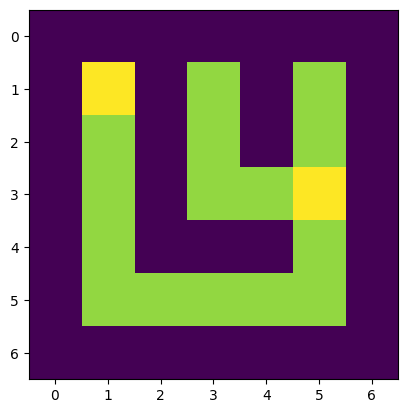

In [37]:
import matplotlib.pyplot as plt
plt.imshow(dataset[0][0][0][0] + dataset[0][0][0][1]*50 + dataset[0][0][0][2]*50)

In [38]:
data = np.load("maze_data.npz")

In [ ]:
data["observations"].shape
(2084, 3, 7, 7)


(2084, 3, 7, 7)

In [66]:
print(data["observations"].reshape(data["observations"].shape[0], -1).std(axis=0).tolist())

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 119.33065032958984, 0.0, 116.7383804321289, 0.0, 0.0, 0.0, 119.51239013671875, 0.0, 124.73099517822266, 0.0, 67.69532775878906, 0.0, 0.0, 0.0, 125.70875549316406, 0.0, 125.79187774658203, 0.0, 0.0, 0.0, 117.93329620361328, 0.0, 126.24175262451172, 0.0, 87.2262954711914, 0.0, 0.0, 0.0, 64.67332458496094, 0.0, 83.42300415039062, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2729801833629608, 0.0, 0.31334352493286133, 0.0, 0.3186400830745697, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2837209105491638, 0.0, 0.3041793406009674, 0.0, 0.3577314019203186, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.286482572555542, 0.0, 0.3415532112121582, 0.0, 0.3326161205768585, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.34000179171562195, 0.0, 0.31154865026474, 0.0, 0.36051619052886963, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.28852835297584534, 0.0, 0.30911901593208313

In [43]:
data["rewards"].mean()

0.2399232245681382

In [50]:
np.array([[[  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ],
        [  0.        ,   0.        , 119.33065   ,   0.        ,
         116.73838   ,   0.        ,   0.        ],
        [  0.        , 119.51239   ,   0.        , 124.730995  ,
           0.        ,  67.69533   ,   0.        ],
        [  0.        ,   0.        , 125.708755  ,   0.        ,
         125.79188   ,   0.        ,   0.        ],
        [  0.        , 117.9333    ,   0.        , 126.24175   ,
           0.        ,  87.226295  ,   0.        ],
        [  0.        ,   0.        ,  64.673325  ,   0.        ,
          83.423004  ,   0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ]],

       [[  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ],
        [  0.        ,   0.27298018,   0.        ,   0.31334352,
           0.        ,   0.31864008,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ],
        [  0.        ,   0.2837209 ,   0.        ,   0.30417934,
           0.        ,   0.3577314 ,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ],
        [  0.        ,   0.28648257,   0.        ,   0.3415532 ,
           0.        ,   0.33261612,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ]],

       [[  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ],
        [  0.        ,   0.3400018 ,   0.        ,   0.31154865,
           0.        ,   0.3605162 ,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ],
        [  0.        ,   0.28852835,   0.        ,   0.30911902,
           0.        ,   0.303549  ,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ],
        [  0.        ,   0.31512254,   0.        ,   0.27949297,
           0.        ,   0.30728027,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ]]]).tolist()

[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.0, 119.33065, 0.0, 116.73838, 0.0, 0.0],
  [0.0, 119.51239, 0.0, 124.730995, 0.0, 67.69533, 0.0],
  [0.0, 0.0, 125.708755, 0.0, 125.79188, 0.0, 0.0],
  [0.0, 117.9333, 0.0, 126.24175, 0.0, 87.226295, 0.0],
  [0.0, 0.0, 64.673325, 0.0, 83.423004, 0.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]],
 [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.27298018, 0.0, 0.31334352, 0.0, 0.31864008, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.2837209, 0.0, 0.30417934, 0.0, 0.3577314, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.28648257, 0.0, 0.3415532, 0.0, 0.33261612, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]],
 [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.3400018, 0.0, 0.31154865, 0.0, 0.3605162, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.28852835, 0.0, 0.30911902, 0.0, 0.303549, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.31512254, 0.0, 0.27949297, 0.0, 0.30728027, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0,